## Introduction

This notebook shows training of the EfficientNet-B0 model - Second CNN approach.

## Setup

In [1]:
import os
import json
from datetime import datetime, timezone
import boto3
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from skin_lesion_project.processing.image_processing import training_data_transforms, test_val_transforms

from skin_lesion_project.datasets.dataloader import create_dataloaders
from skin_lesion_project.models.efficientnet import get_efficientnet_b0
from skin_lesion_project.training.train import train

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

NUM_CLASSES = 8
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

Device : cuda
GPU : NVIDIA RTX A4000


In [3]:
DEVICE

device(type='cuda')

## Data Loaders

In [4]:
train_loader, val_loader, class_weights = create_dataloaders(
    train_transform=training_data_transforms(),
    val_transform=test_val_transforms(),
    train_image_dir="/home/shadeform/data/train",
    train_label_file="/home/shadeform/data/labels/mappings.pkl",
    val_image_dir="/home/shadeform/data/test",
    val_label_file="/home/shadeform/data/labels/mappings_test.pkl",
    batch_size=BATCH_SIZE,
)

Training Images   : 30931
Validation Images : 8238
Batch Size        : 32
Workers           : 16


## Images

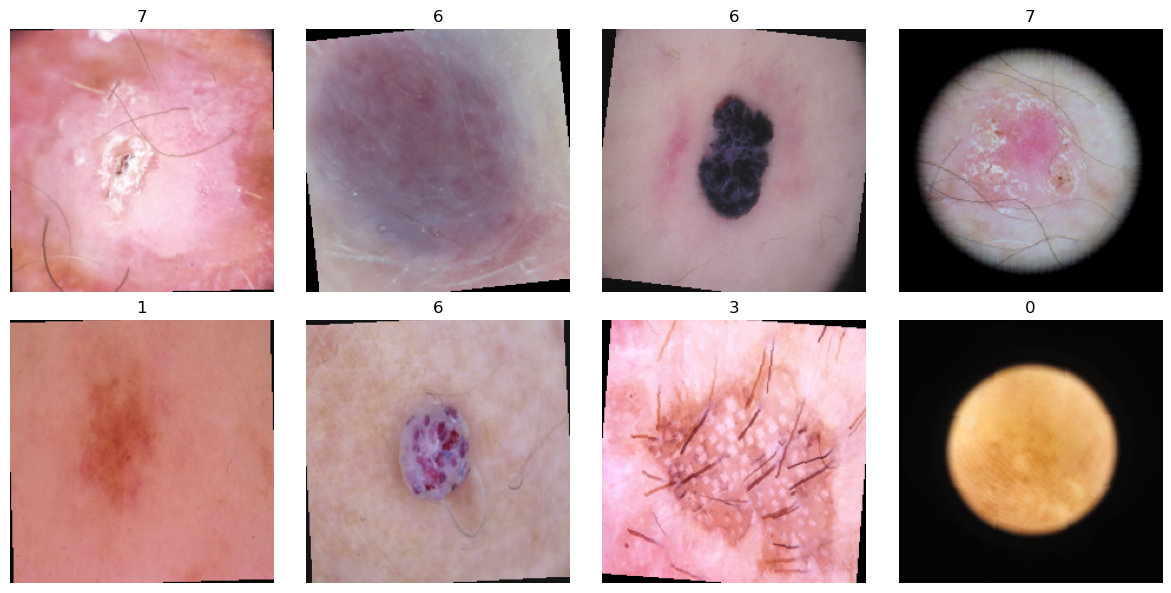

In [5]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, ax in enumerate(axes.flat):
    image = images[i].cpu()
    image = image * std + mean
    image = image.clamp(0, 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(labels[i].item())
    ax.axis("off")
plt.tight_layout()
plt.show()

## EfficientNet-B0 Model

In [6]:
model = get_efficientnet_b0(num_classes=NUM_CLASSES, pretrained=True)
model.freeze_backbone()
model.to(DEVICE)
model.summary()

Model            : EfficientNet-B0
Output Classes   : 8
Feature Dimension: 1280
Trainable Params : 10,248


## Model Training

In [7]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)

EPOCHS_FROZEN = 30
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_FROZEN)

history_frozen = train(
    model=model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    device=DEVICE, epochs=EPOCHS_FROZEN,
    checkpoint_path="checkpoints/efficientnet_b0_classifier.pt",
    early_stopping_patience=7,
)

Epoch 1/30: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:43<00:00, 22.24it/s, loss=1.2847]


Best model saved.
Epoch 1/30
Train Loss : 1.3078393317352677
Val Loss   : 2.340473898060839
Train Acc  : 0.26239048204067117
Val Acc    : 0.04697742170429716
Precision  : 0.27807659770043286
Recall     : 0.2842196316628838
Macro F1   : 0.05491692360216889


Epoch 2/30: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:42<00:00, 22.60it/s, loss=0.8856]


Best model saved.
Epoch 2/30
Train Loss : 0.9950420867960867
Val Loss   : 2.232828037806523
Train Acc  : 0.3336458569073098
Val Acc    : 0.07344015537751881
Precision  : 0.24657297631451516
Recall     : 0.3165826797264829
Macro F1   : 0.08356445343009741


Epoch 3/30: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:41<00:00, 23.08it/s, loss=0.6167]


...

Epoch 27/30
Train Loss : 0.6285678030817806
Val Loss   : 2.288955661705843
Train Acc  : 0.486987164980117
Val Acc    : 0.1637533381888808
Precision  : 0.3031532488447244
Recall     : 0.3723022826124034
Macro F1   : 0.16536449474305562


Epoch 28/30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:42<00:00, 22.61it/s, loss=0.3909]


Epoch 28/30
Train Loss : 0.6414035099520684
Val Loss   : 2.2460721507180113
Train Acc  : 0.48142640069832854
Val Acc    : 0.17055110463704784
Precision  : 0.3055328435987541
Recall     : 0.3741638294848633
Macro F1   : 0.16621956869739582


Epoch 29/30: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:41<00:00, 23.24it/s, loss=0.4425]


Epoch 29/30
Train Loss : 0.6397985629071351
Val Loss   : 2.32713438698203
Train Acc  : 0.47864601855743427
Val Acc    : 0.16047584365137169
Precision  : 0.30161397533174983
Recall     : 0.3657940780337759
Macro F1   : 0.15943590313658984

Early stopping triggered at epoch 29/30 (no improvement in Macro F1 for 7 epochs)
Best Validation Macro F1 : 0.16751504688899413


## Fine Tuning

In [8]:
model.load_state_dict(torch.load("checkpoints/efficientnet_b0_classifier.pt", map_location=DEVICE))
model.unfreeze_last_block()

head_params = [p for n, p in model.named_parameters() if "backbone.classifier" in n]
last_block_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and "backbone.classifier" not in n]

optimizer = AdamW([
    {"params": last_block_params, "lr": 1e-5},
    {"params": head_params, "lr": 1e-4},
], weight_decay=5e-4)

EPOCHS_FINETUNE = 100
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

history_finetune = train(
    model=model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    device=DEVICE, epochs=EPOCHS_FINETUNE,
    checkpoint_path="checkpoints/efficientnet_b0_finetuned.pt",
    early_stopping_patience=7,
)

/tmp/ipykernel_21180/3933897194.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("checkpoints/efficientnet_b0_classifier.pt", map_locatio

Best model saved.
Epoch 1/100
Train Loss : 0.6241147339744845
Val Loss   : 2.2521089711910487
Train Acc  : 0.48385115256538747
Val Acc    : 0.17055110463704784
Precision  : 0.3050921315944043
Recall     : 0.3697985938648179
Macro F1   : 0.16645667322391033


Epoch 2/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:43<00:00, 22.06it/s, loss=0.6921]


Best model saved.
Epoch 2/100
Train Loss : 0.598135286273027
Val Loss   : 2.270732621858351
Train Acc  : 0.4951343312534351
Val Acc    : 0.1726147123088128
Precision  : 0.305248419553841
Recall     : 0.37626448253525757
Macro F1   : 0.16872067099159793


Epoch 3/100: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:42<00:00, 22.95it/s, loss=0.5121]


...

Epoch 27/100
Train Loss : 0.35861452713202624
Val Loss   : 2.2923047263577714
Train Acc  : 0.5956807086741457
Val Acc    : 0.22638990046127702
Precision  : 0.3066666397668767
Recall     : 0.4226220683826113
Macro F1   : 0.21304409044657036


Epoch 28/100: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:43<00:00, 22.27it/s, loss=0.3095]


Epoch 28/100
Train Loss : 0.34984871989937405
Val Loss   : 2.276850523720612
Train Acc  : 0.6032136044744755
Val Acc    : 0.2229910172371935
Precision  : 0.30721208154044155
Recall     : 0.41105097119982026
Macro F1   : 0.2081239446400136


Epoch 29/100: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 967/967 [00:44<00:00, 21.89it/s, loss=0.3310]


Epoch 29/100
Train Loss : 0.3524556498829915
Val Loss   : 2.2773748983252133
Train Acc  : 0.5976528401926869
Val Acc    : 0.22469045884923525
Precision  : 0.3110402000157514
Recall     : 0.41687938209649894
Macro F1   : 0.2098162260722411

Early stopping triggered at epoch 29/100 (no improvement in Macro F1 for 7 epochs)
Best Validation Macro F1 : 0.21730452668625969


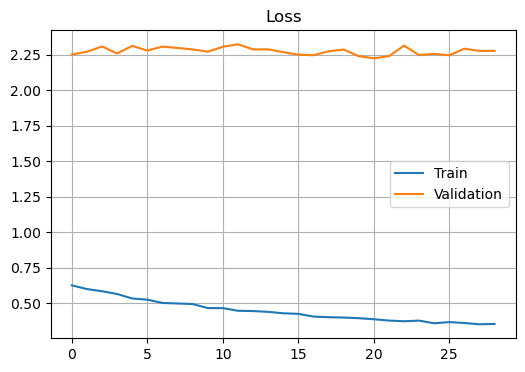

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(history_finetune["train_loss"], label="Train")
plt.plot(history_finetune["val_loss"], label="Validation")
plt.title("Loss")
plt.grid(True)
plt.legend()
plt.show()

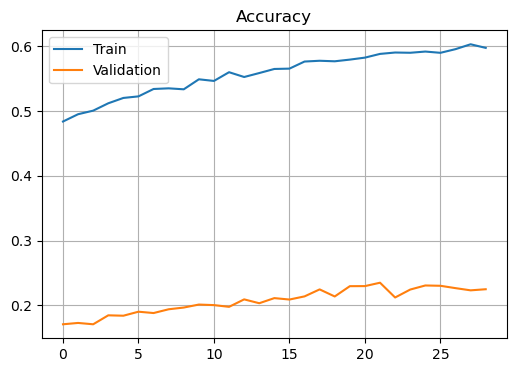

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(history_finetune["train_accuracy"], label="Train")
plt.plot(history_finetune["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

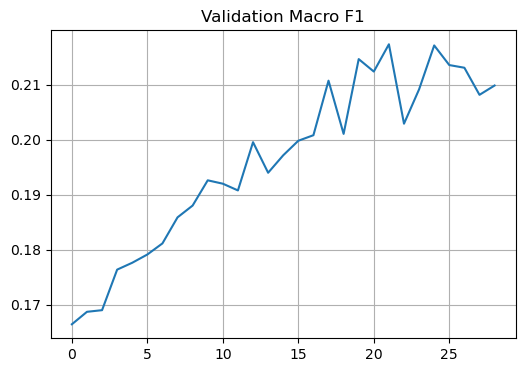

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(history_finetune["macro_f1"])
plt.title("Validation Macro F1")
plt.grid(True)
plt.show()

In [12]:
print(f"Best Validation Accuracy : {max(history_finetune['val_accuracy']):.4f}")
print(f"Best Validation Macro F1 : {max(history_finetune['macro_f1']):.4f}")

Best Validation Accuracy : 0.2348
Best Validation Macro F1 : 0.2173


## Model Saving

In [13]:
BUCKET_NAME = "skin-lesion-data-bucket"
MODEL_FOLDER = "models/efficientnet_b0"
s3 = boto3.client("s3")

In [14]:
os.makedirs("saved_models/efficientnet_b0", exist_ok=True)

In [15]:
checkpoint = {
    "model_name": "EfficientNetB0",
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "class_to_idx": {
        "MEL": 0,
        "NV": 1,
        "BCC": 2,
        "AK": 3,
        "BKL": 4,
        "DF": 5,
        "VASC": 6,
        "SCC": 7,
    },
    "num_classes": NUM_CLASSES,
}

torch.save(checkpoint, "saved_models/efficientnet_b0/efficientnet_b0_checkpoint.pth")

In [16]:
class_mapping = {
    0: "MEL",
    1: "NV",
    2: "BCC",
    3: "AK",
    4: "BKL",
    5: "DF",
    6: "VASC",
    7: "SCC",
}

with open("saved_models/efficientnet_b0/class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=4)

In [17]:
config = {
    "model_name": "EfficientNetB0",
    "architecture": "EfficientNet-B0",
    "version": "1.0.0",
    "created_at": datetime.now(timezone.utc).isoformat(),
    "image_size": 224,
    "num_classes": NUM_CLASSES,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "loss": "CrossEntropyLoss",
    "label_smoothing": 0.1,
    "classes": [
        "MEL",
        "NV",
        "BCC",
        "AK",
        "BKL",
        "DF",
        "VASC",
        "SCC",
    ],
}

with open("saved_models/efficientnet_b0/model_config.json", "w") as f:
    json.dump(config, f, indent=4)

In [18]:
history_df = pd.DataFrame(history_finetune)
history_df.to_csv("saved_models/efficientnet_b0/training_history.csv", index=False)

In [19]:
metrics = {
    "best_validation_accuracy": float(max(history_finetune["val_accuracy"])),
    "best_macro_f1": float(max(history_finetune["macro_f1"])),
    "epochs": len(history_finetune["val_accuracy"]),
}

with open("saved_models/efficientnet_b0/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [20]:
files_to_upload = {
    "saved_models/efficientnet_b0/efficientnet_b0_checkpoint.pth":
        f"{MODEL_FOLDER}/efficientnet_b0_checkpoint.pth",

    "saved_models/efficientnet_b0/model_config.json":
        f"{MODEL_FOLDER}/model_config.json",

    "saved_models/efficientnet_b0/class_mapping.json":
        f"{MODEL_FOLDER}/class_mapping.json",

    "saved_models/efficientnet_b0/training_history.csv":
        f"{MODEL_FOLDER}/training_history.csv",

    "saved_models/efficientnet_b0/metrics.json":
        f"{MODEL_FOLDER}/metrics.json",
}

for local_file, s3_key in files_to_upload.items():
    s3.upload_file(local_file, BUCKET_NAME, s3_key)
    print(f"Uploaded -> s3://{BUCKET_NAME}/{s3_key}")

print("All model artifacts uploaded successfully!")

Uploaded -> s3://skin-lesion-data-bucket/models/efficientnet_b0/efficientnet_b0_checkpoint.pth
Uploaded -> s3://skin-lesion-data-bucket/models/efficientnet_b0/model_config.json
Uploaded -> s3://skin-lesion-data-bucket/models/efficientnet_b0/class_mapping.json
Uploaded -> s3://skin-lesion-data-bucket/models/efficientnet_b0/training_history.csv
Uploaded -> s3://skin-lesion-data-bucket/models/efficientnet_b0/metrics.json
All model artifacts uploaded successfully!
